In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Use a clean, accessible theme with good default styling
sns.set_theme(
    style="whitegrid",      # Adds a subtle grid that helps read values
    context="talk",         # Slightly larger text for notebook charts
    palette="colorblind"    # Accessible palette with good contrast
)

# Set Matplotlib defaults for a simple look
plt.rcParams.update({
    "figure.facecolor": "white",   # White figure background
    "axes.facecolor": "white",     # White plotting area
    "axes.edgecolor": "#333333",   # Dark grey axis lines
    "axes.labelcolor": "#222222",  # Dark grey axis labels
    "xtick.color": "#222222",      # Dark grey tick labels
    "ytick.color": "#222222",      # Dark grey tick labels
    "text.color": "#222222",       # Default text colour
    "grid.color": "#D9D9D9",       # Light grey grid lines
    "grid.linewidth": 0.8,         # Thin grid lines
    "axes.titleweight": "bold",    # Bold chart titles
    "font.size": 11                # Base font size
})


In [3]:
# Load the season summary sheet from the Excel file
season = pd.read_excel("premier_league_summaries.xlsx", sheet_name="season_summary")

# Extract the starting year from the season string, e.g. "1992/93" -> 1992
season["start_year"] = season["season"].astype(str).str.extract(r"(\d{4})").astype(int)

# Sort the data chronologically so the chart runs left to right in time order
season = season.sort_values("start_year")

<Axes: xlabel='season', ylabel='top10_total_goals'>

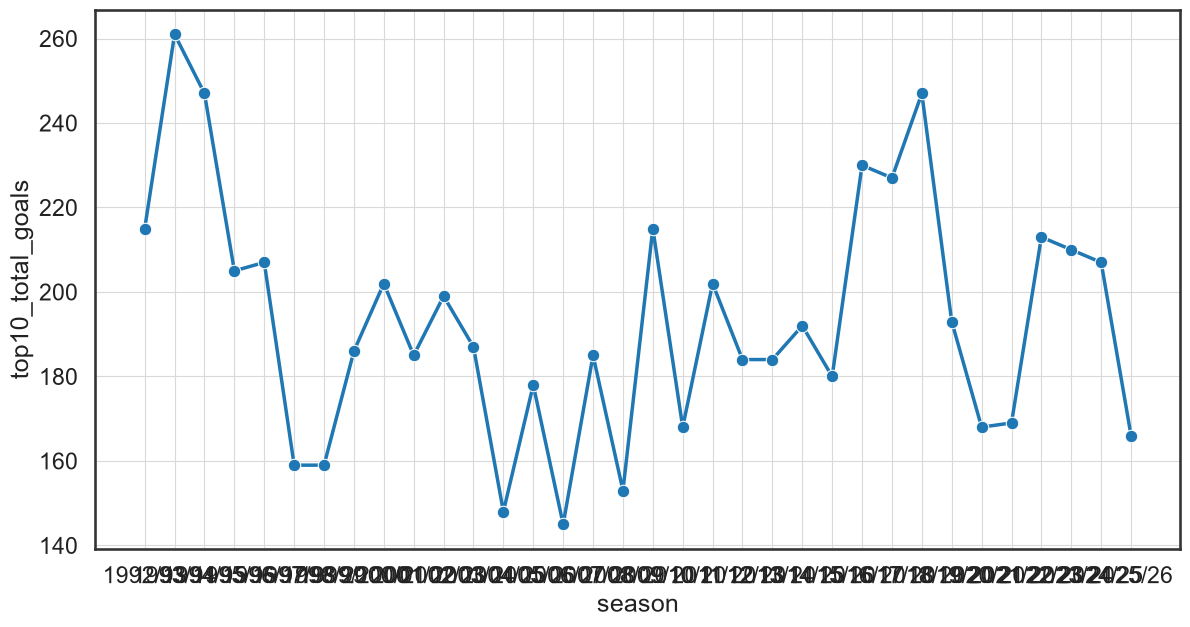

In [4]:
# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Draw a line chart for total top 10 goals by season
sns.lineplot(
    data=season,
    x="season",
    y="top10_total_goals",
    marker="o",             # Show a point at each season
    linewidth=2.5,          # Slightly thicker line for clarity
    color="#1F77B4",        # Blue accent colour
    ax=ax
)

In [5]:
# Fill the area under the line to make the trend easier to see
ax.fill_between(
    season["season"],
    season["top10_total_goals"],
    color="#1F77B4",
    alpha=0.12              # Very light fill so it doesn't overpower the line
)

In [6]:
# Add title and axis labels
ax.set_title("Top 10 goals by season (1992/93-2025/26)", pad=16)
ax.set_xlabel("Season")
ax.set_ylabel("Goals")

# Rotate x-axis labels so they don't overlap
ax.tick_params(axis="x", rotation=45)

# Keep only horizontal grid lines for readability
ax.grid(True, axis="y")

# Remove top and right borders for a cleaner look
sns.despine(ax=ax)

# Make layout neat so labels don't get cut off
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [7]:
plt.show()

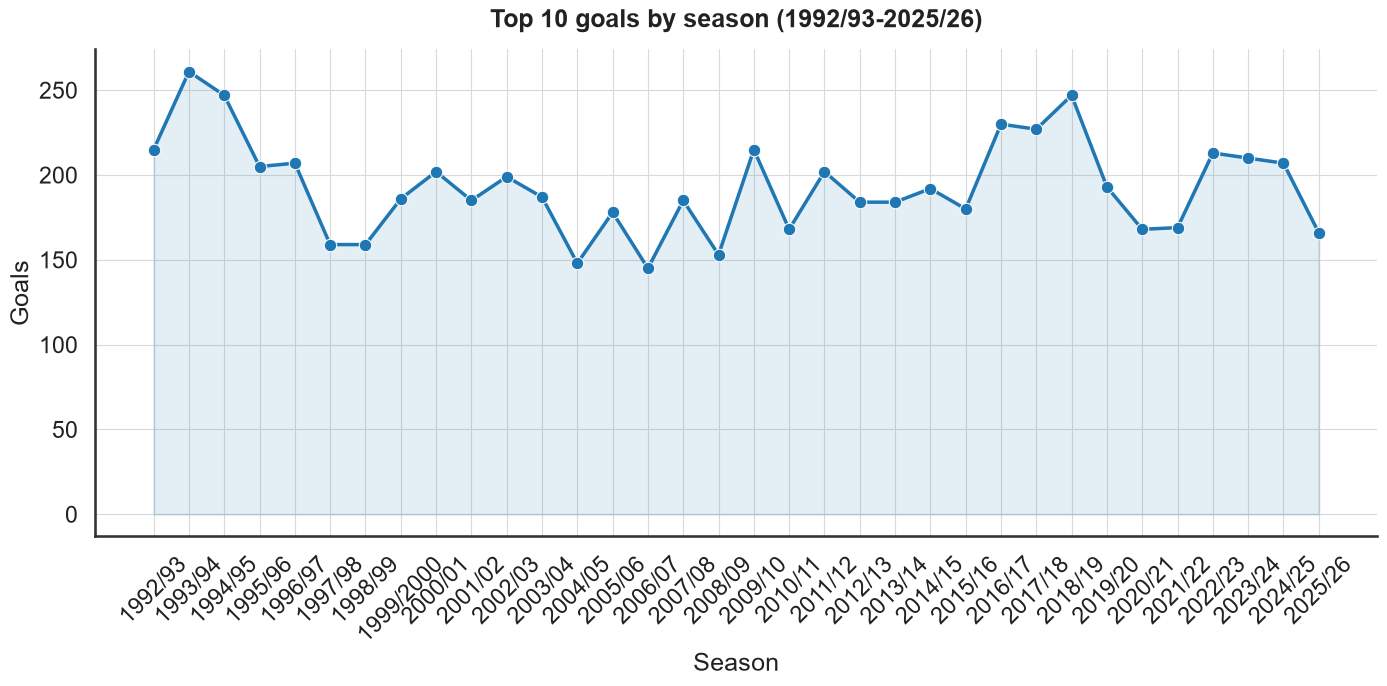

In [ ]:
# Load the season summary sheet from the Excel file
season = pd.read_excel("premier_league_summaries.xlsx", sheet_name="season_summary")

# Extract the starting year from the season string, e.g. "1992/93" -> 1992
season["start_year"] = season["season"].astype(str).str.extract(r"(\d{4})").astype(int)

# Sort the data chronologically so the chart runs left to right in time order
season = season.sort_values("start_year")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Draw a line chart for total top 10 goals by season
sns.lineplot(
    data=season,
    x="season",
    y="top10_total_goals",
    marker="o",             # Show a point at each season
    linewidth=2.5,          # Slightly thicker line for clarity
    color="#1F77B4",        # Blue accent colour
    ax=ax
)

# Fill the area under the line to make the trend easier to see
ax.fill_between(
    season["season"],
    season["top10_total_goals"],
    color="#1F77B4",
    alpha=0.12              # Very light fill so it doesn't overpower the line
)

# Add title and axis labels
ax.set_title("Top 10 goals by season (1992/93-2025/26)", pad=16)
ax.set_xlabel("Season")
ax.set_ylabel("Goals")

# Rotate x-axis labels so they don't overlap
ax.tick_params(axis="x", rotation=45)

# Keep only horizontal grid lines for readability
ax.grid(True, axis="y")

# Remove top and right borders for a cleaner look
sns.despine(ax=ax)

# Make layout neat so labels don't get cut off
plt.tight_layout()

# Show the chart in the notebook
plt.show()

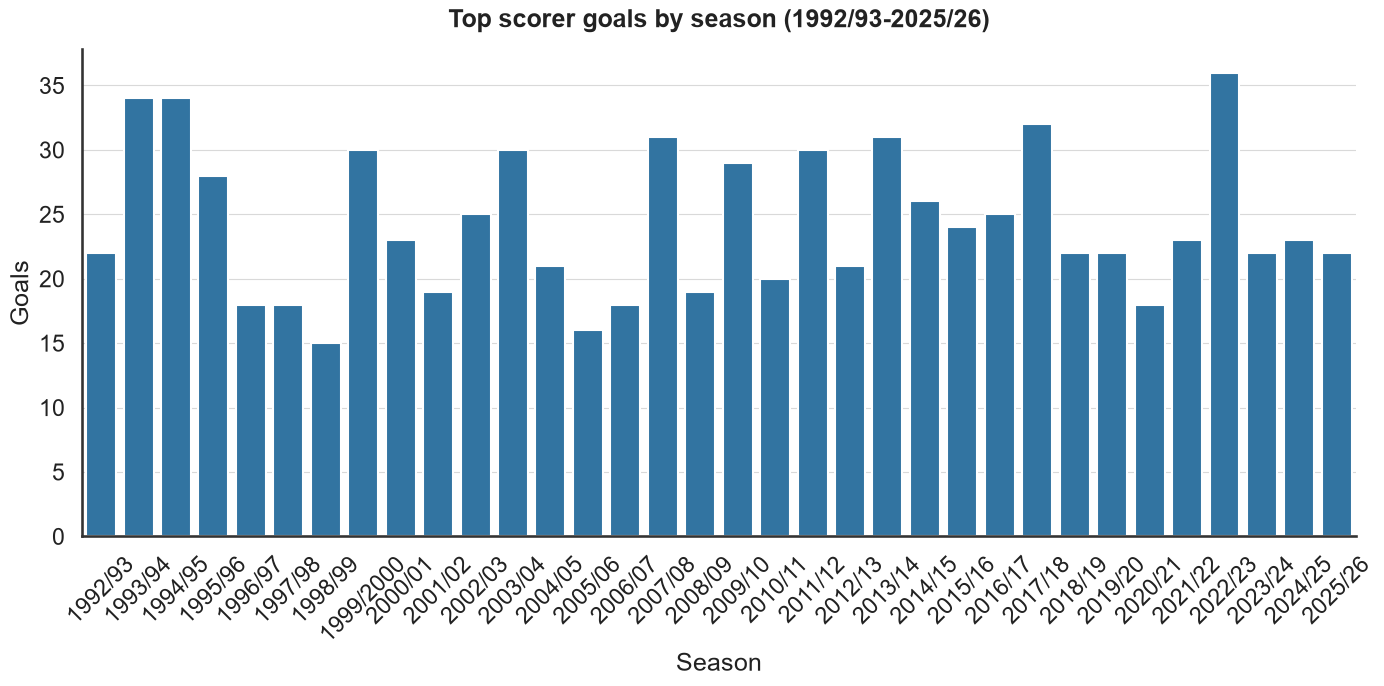

In [9]:
# Load the player summary sheet from the Excel file
player = pd.read_excel("premier_league_summaries.xlsx", sheet_name="player_goals")

# Build a season-level table showing the highest scorer total in each season
season_best = (
    player.groupby("best_season", as_index=False)
          .agg(best_season_goals=("best_season_goals", "max"))
)

# Extract the starting year so the seasons can be sorted chronologically
season_best["start_year"] = season_best["best_season"].astype(str).str.extract(r"(\d{4})").astype(int)

# Sort from earliest to latest season
season_best = season_best.sort_values("start_year")

# Create the figure and axis
fig, ax = plt.subplots(figsize=(14, 7))

# Draw a bar chart for the top scorer total in each season
sns.barplot(
    data=season_best,
    x="best_season",
    y="best_season_goals",
    color="#1F77B4",        # Same blue accent for consistency
    ax=ax
)

# Add title and labels
ax.set_title("Top scorer goals by season (1992/93-2025/26)", pad=16)
ax.set_xlabel("Season")
ax.set_ylabel("Goals")

# Rotate season labels so they fit more easily
ax.tick_params(axis="x", rotation=45)

# Add horizontal grid lines to make the bar heights easier to compare
ax.grid(True, axis="y")

# Remove top and right borders for a cleaner appearance
sns.despine(ax=ax)

# Improve spacing
plt.tight_layout()

# Save the chart as a PNG file
plt.savefig("top_scorer_by_season_matplotlib.png", dpi=300, bbox_inches="tight")

# Display the chart
plt.show()

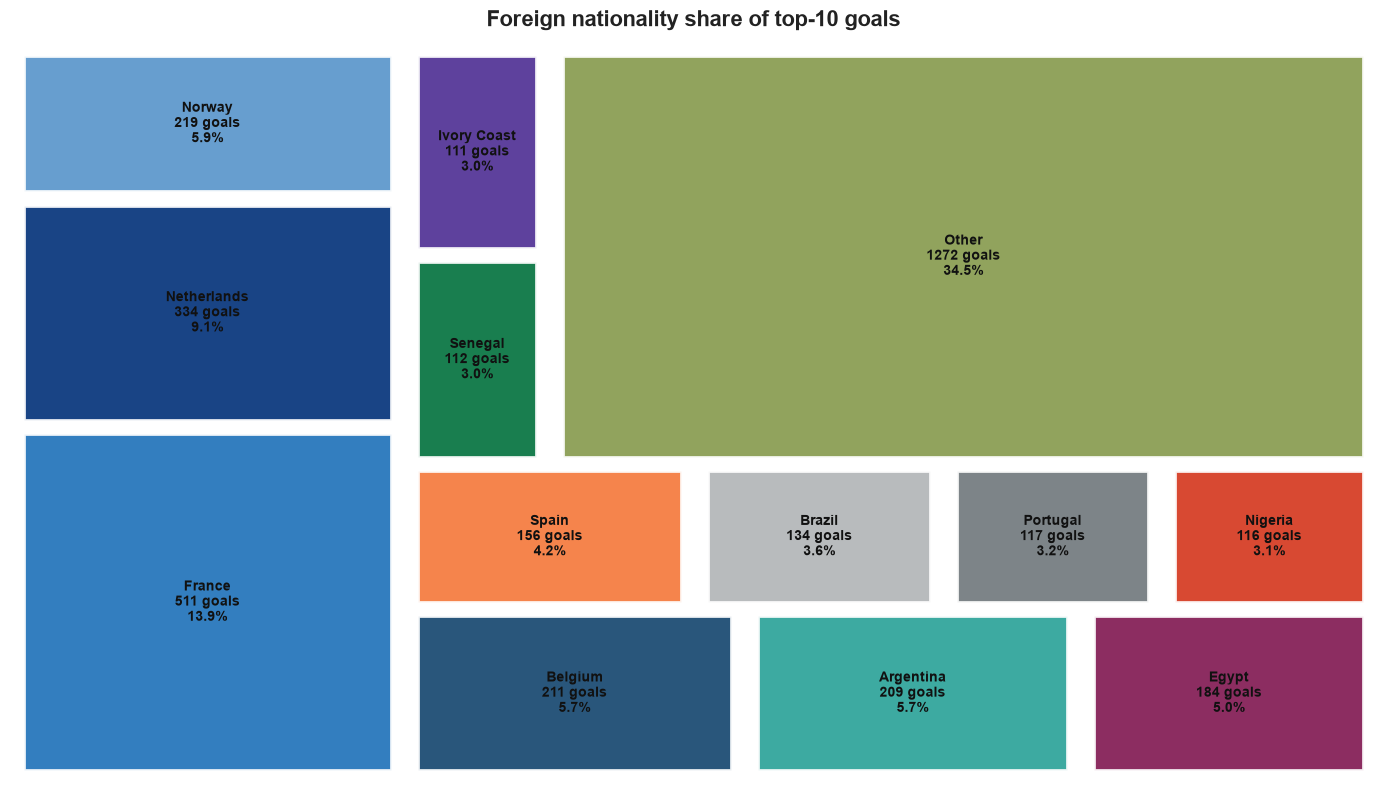

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify  # pip install squarify

# --------------------------------------------------
# 1. LOAD DATA FROM THE SUMMARY EXCEL FILE
# --------------------------------------------------
# Read the nationality summary sheet directly from the workbook
nationality_summary = pd.read_excel(
    "premier_league_summaries.xlsx",
    sheet_name="nationality_summary"
)

# --------------------------------------------------
# 2. FILTER OUT ENGLAND
# --------------------------------------------------
# Keep only foreign nationalities
foreign_nat = nationality_summary[
    nationality_summary["nationality"] != "England"
].copy()

# --------------------------------------------------
# 3. SORT BY TOTAL GOALS
# --------------------------------------------------
# Largest groups first works best for a treemap layout
foreign_nat = foreign_nat.sort_values(
    "total_top10_goals",
    ascending=False
)

# --------------------------------------------------
# 4. OPTIONAL: KEEP TOP N + GROUP OTHERS
# --------------------------------------------------
# Treemaps can get messy with too many small boxes,
# so keeping the biggest groups and combining the rest
# usually makes the chart much easier to read
top_n = 12

top_foreign = foreign_nat.head(top_n).copy()
other_goals = foreign_nat.iloc[top_n:]["total_top10_goals"].sum()

if other_goals > 0:
    other_row = pd.DataFrame({
        "nationality": ["Other"],
        "total_top10_goals": [other_goals]
    })
    top_foreign = pd.concat([top_foreign, other_row], ignore_index=True)

# --------------------------------------------------
# 5. CALCULATE SHARE FOR LABELS
# --------------------------------------------------
# This gives a percentage of total foreign-player goals
top_foreign["goal_share"] = (
    top_foreign["total_top10_goals"] /
    top_foreign["total_top10_goals"].sum()
) * 100

# Create labels with nationality, goals and %
top_foreign["label"] = (
    top_foreign["nationality"] + "\n" +
    top_foreign["total_top10_goals"].round(0).astype(int).astype(str) + " goals\n" +
    top_foreign["goal_share"].round(1).astype(str) + "%"
)

# --------------------------------------------------
# 6. SET STYLE
# --------------------------------------------------
# Use a clean, accessible style
sns.set_theme(style="white")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "text.color": "#222222",
    "font.size": 11
})

# GOV.UK-inspired accessible colours
colors = [
    "#1D70B8", "#003078", "#5694CA", "#12436D", "#28A197",
    "#801650", "#F47738", "#B1B4B6", "#6F777B", "#D4351C",
    "#00703C", "#4C2C92", "#85994B"
]

# --------------------------------------------------
# 7. CREATE TREEMAP
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 8))

squarify.plot(
    sizes=top_foreign["total_top10_goals"],
    label=top_foreign["label"],
    color=colors[:len(top_foreign)],
    alpha=0.9,
    pad=True,
    text_kwargs={
        "fontsize": 10,
        "color": "#111111",
        "weight": "bold"
    },
    bar_kwargs={
        "edgecolor": "white",
        "linewidth": 2
    },
    ax=ax
)

# Remove axes for a cleaner treemap
ax.axis("off")

# Add title
plt.title(
    "Foreign nationality share of top-10 goals",
    fontsize=16,
    fontweight="bold",
    pad=16
)

# --------------------------------------------------
# 8. SAVE AND SHOW
# --------------------------------------------------
plt.tight_layout()
plt.savefig("foreign_nationality_treemap.png", dpi=300, bbox_inches="tight")
plt.show()